 **Imported** **Libraries**

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.metrics import (
    roc_curve, precision_recall_curve, auc, average_precision_score,
    precision_score, recall_score, f1_score, confusion_matrix,
    roc_auc_score
)

**Load Dataset and Basic Overview**

In [3]:
df = pd.read_csv('heart.csv')
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None


In [5]:
print(df.describe())

              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997  131.623762  246.264026    0.148515   
std      9.082101    0.466011    1.032052   17.538143   51.830751    0.356198   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     47.500000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.000000    1.000000    1.000000  130.000000  240.000000    0.000000   
75%     61.000000    1.000000    2.000000  140.000000  274.500000    0.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean     0.528053  149.646865    0.326733    1.039604    1.399340    0.729373   
std      0.525860   22.9051

**Feature Selection**

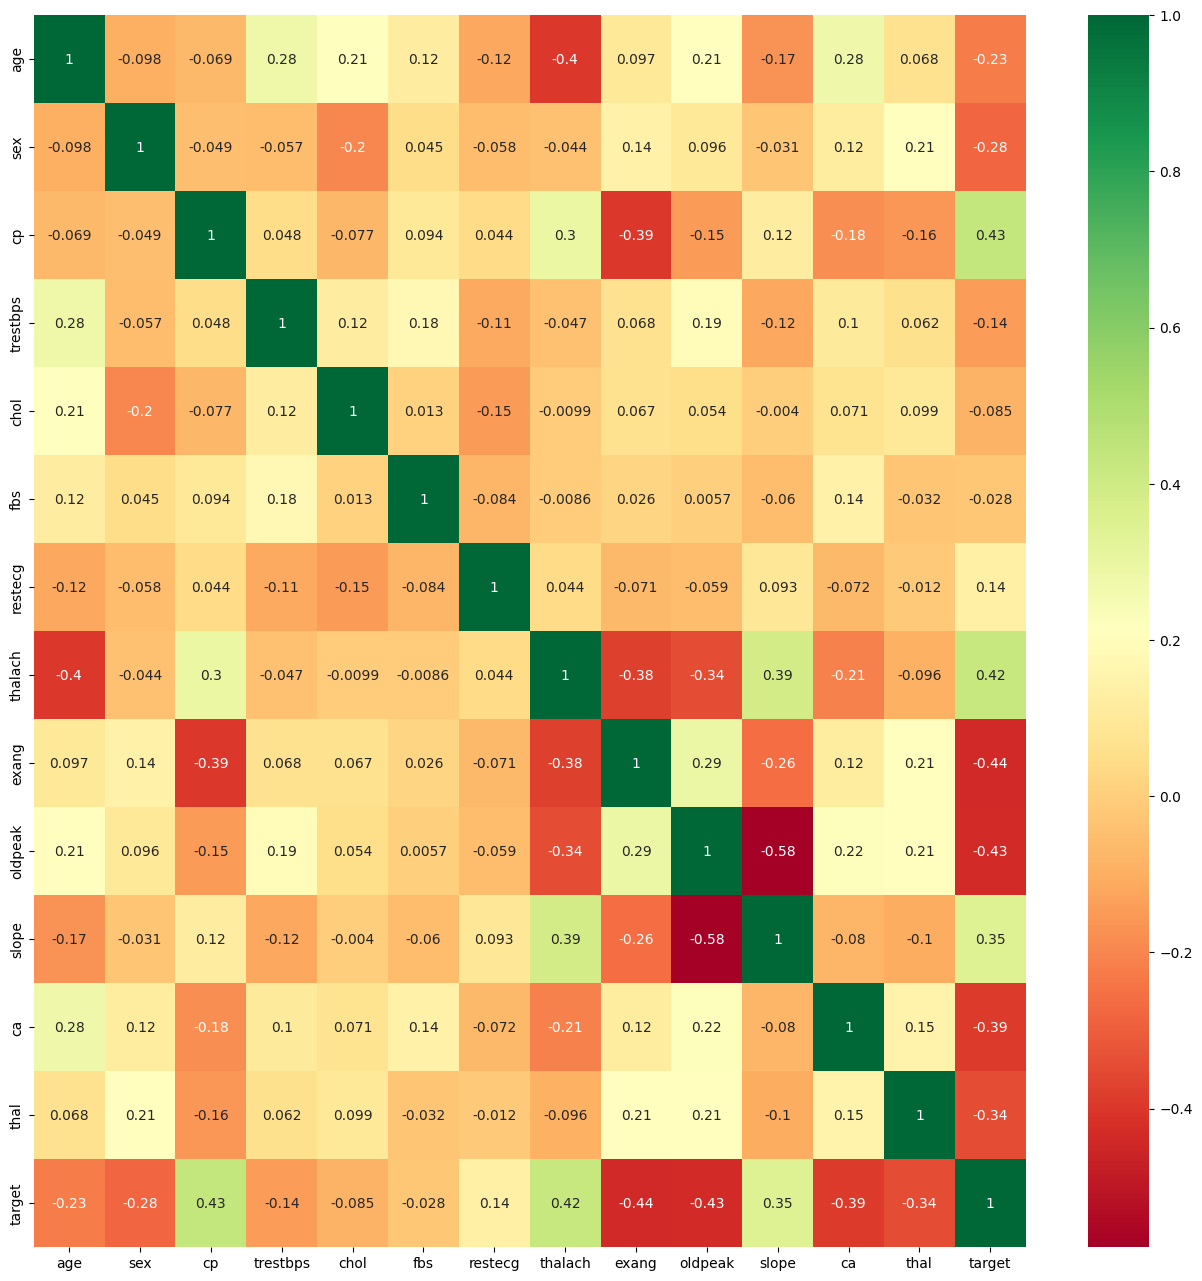

In [6]:
import seaborn as sns
corrmat = df.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(16,16))
#plot heat map
g=sns.heatmap(df[top_corr_features].corr(),annot=True,cmap="RdYlGn")
plt.show()

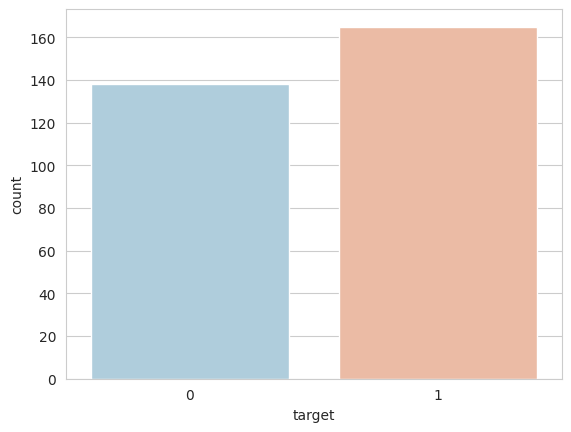

In [7]:
sns.set_style('whitegrid')
sns.countplot(x='target',data=df,palette='RdBu_r')
plt.show()

**Split Dataset and Define Numerical/Categorical Features**

In [7]:
# Split features/target
y = df["target"]
X = df.drop(columns=["target"])

In [8]:
# Columns
num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
cat_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

In [12]:
# Preprocessing pipeline for numeric and categorical features
preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),   # Scale numeric features
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)  # Encode categorical features
])


In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [15]:
# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


**Model Training**

**KNN — Hyperparameter Tuning and Balanced Selection**

Balanced KNN selection:
  params: {'classifier__n_neighbors': 9, 'classifier__p': 1, 'classifier__weights': 'uniform'}
  CV AUC: 0.903  |  gap(train−cv): 0.041

Test metrics @0.5: AUC=0.887, F1=0.800, P=0.714, R=0.909
Confusion matrix:
 [[16 12]
 [ 3 30]]


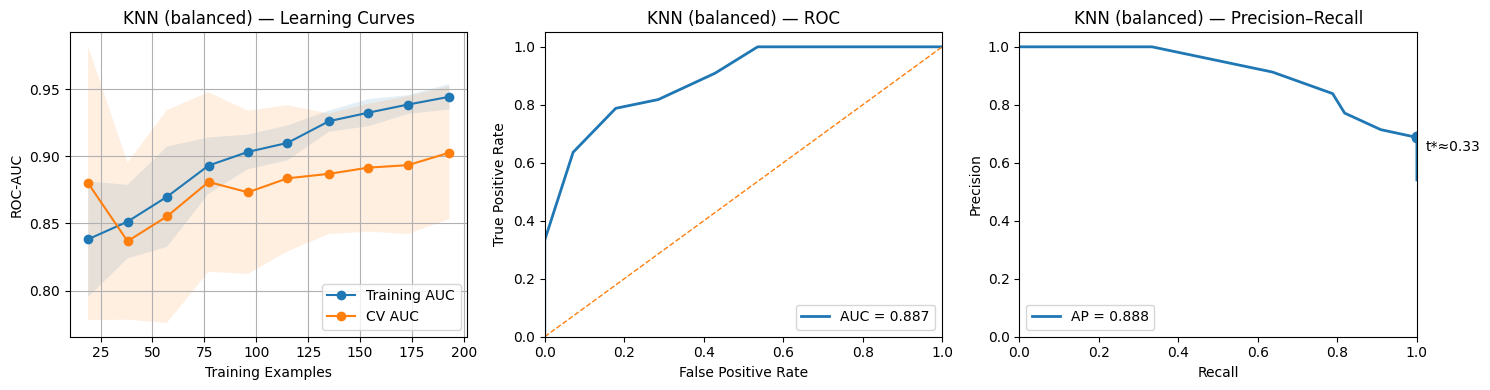

In [16]:
# KNN pipeline (same as before)
pipe_knn = Pipeline([
    ("prep", preprocess),
    ("classifier", KNeighborsClassifier())
])

# Wider search range for k
param_grid_knn = {
    "classifier__n_neighbors": list(range(3, 32, 2)),   # 3, 5, ..., 31
    "classifier__weights": ["uniform", "distance"],
    "classifier__p": [1, 2],                            # Manhattan / Euclidean
}

# Grid search — must set return_train_score=True
gs_knn_raw = GridSearchCV(
    pipe_knn,
    param_grid_knn,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    refit=False,
    return_train_score=True
)
gs_knn_raw.fit(X_train, y_train)

# Store results as a DataFrame
cvres = pd.DataFrame(gs_knn_raw.cv_results_)
cvres["gap"] = cvres["mean_train_score"] - cvres["mean_test_score"]

# 1) If there are models with a small train–test gap, choose the one with the highest test AUC
GAP_MAX = 0.05
subset = cvres[cvres["gap"] <= GAP_MAX]

if len(subset) > 0:
    best_row = subset.sort_values("mean_test_score", ascending=False).iloc[0]
else:
    # 2) Otherwise, select based on a balanced objective function
    alpha = 0.5  # penalty weight for overfitting
    cvres["objective"] = cvres["mean_test_score"] - alpha * cvres["gap"]
    best_row = cvres.sort_values("objective", ascending=False).iloc[0]

best_params = best_row["params"]
best_test_auc = best_row["mean_test_score"]
best_gap = best_row["gap"]

print("Balanced KNN selection:")
print("  params:", best_params)
print(f"  CV AUC: {best_test_auc:.3f}  |  gap(train−cv): {best_gap:.3f}")

# Final model with the selected parameters
knn_balanced = pipe_knn.set_params(**best_params)
knn_balanced.fit(X_train, y_train)

# Evaluation on the test set (ROC, PR, LC, etc.)
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix

y_proba = knn_balanced.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)
print("\nTest metrics @0.5:",
      f"AUC={roc_auc_score(y_test, y_proba):.3f},",
      f"F1={f1_score(y_test, y_pred):.3f},",
      f"P={precision_score(y_test, y_pred):.3f},",
      f"R={recall_score(y_test, y_pred):.3f}")
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

# ----- Learning curve (AUC metric)
train_sizes, train_scores, val_scores = learning_curve(
    knn_balanced, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv, scoring="roc_auc", n_jobs=-1
)
train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std     = val_scores.mean(axis=1),  val_scores.std(axis=1)

# ----- ROC & PR curves
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

prec, rec, pr_thr = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

# Optimal F1 threshold from PR curve
f1_curve = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-12)
opt_idx = int(np.argmax(f1_curve))
t_star = pr_thr[opt_idx]  # optimal threshold
r_star, p_star = rec[opt_idx], prec[opt_idx]

# ----- Plot: One row, three charts
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (1) Learning curve
ax = axes[0]
ax.plot(train_sizes, train_mean, marker='o', label='Training AUC')
ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.12)
ax.plot(train_sizes, val_mean, marker='o', label='CV AUC')
ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.12)
ax.set_xlabel('Training Examples'); ax.set_ylabel('ROC-AUC')
ax.set_title('KNN (balanced) — Learning Curves')
ax.legend(loc='lower right'); ax.grid(True)

# (2) ROC curve
ax = axes[1]
ax.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
ax.plot([0,1],[0,1], lw=1, linestyle='--')
ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('KNN (balanced) — ROC'); ax.legend(loc='lower right')

# (3) Precision–Recall curve
ax = axes[2]
ax.plot(rec, prec, lw=2, label=f'AP = {ap:.3f}')
ax.scatter(r_star, p_star, s=60)  # optimal threshold point
ax.annotate(f"t*≈{t_star:.2f}", (r_star, p_star),
            textcoords="offset points", xytext=(6, -10))
ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('KNN (balanced) — Precision–Recall'); ax.legend(loc='lower left')

plt.tight_layout()
plt.show()


**Random Forest — Hyperparameter Tuning and Balanced Selection**

Balanced RF selection:
  params: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 5, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 400}
  CV AUC: 0.894  |  gap(train−cv): 0.087

Test metrics @0.5: AUC=0.915, F1=0.817, P=0.763, R=0.879
Confusion matrix:
 [[19  9]
 [ 4 29]]


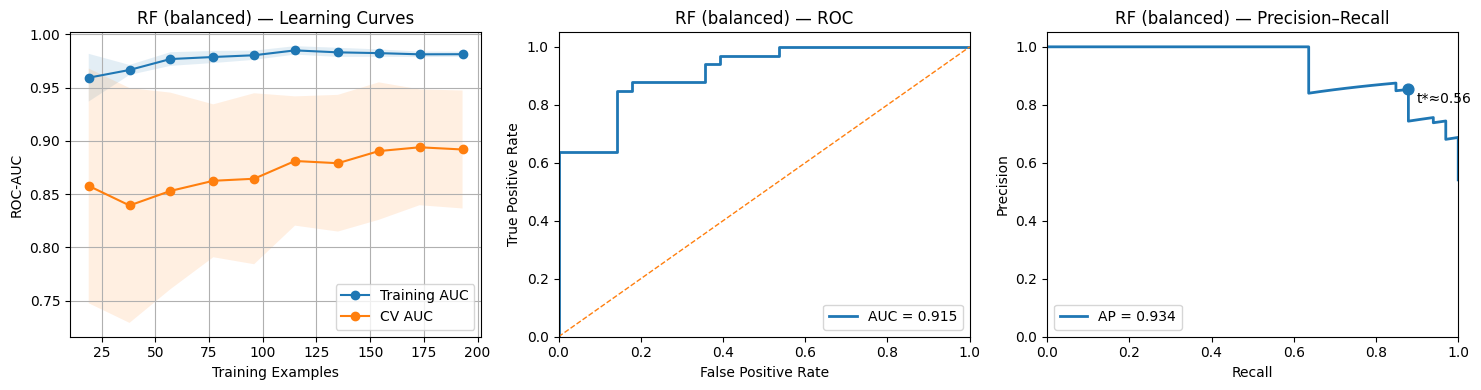


Metrics on TEST @ t* (F1-optimal)
AUC=0.915  AP=0.934  F1=0.866  P=0.853  R=0.879
Confusion matrix @ t*:
 [[23  5]
 [ 4 29]]


In [18]:
# ---- RandomForest pipeline
pipe_rf = Pipeline([
    ("prep", preprocess),
    ("classifier", RandomForestClassifier(random_state=42))
])

# ---- Hyperparameter grid
param_grid_rf = {
    "classifier__n_estimators": [100, 200, 400],
    "classifier__max_depth": [None, 5, 10, 20],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__class_weight": [None, "balanced"]
}

# ---- Grid search with storing Train/CV scores
gs_rf_raw = GridSearchCV(
    pipe_rf,
    param_grid_rf,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    refit=False,
    return_train_score=True
)
gs_rf_raw.fit(X_train, y_train)

# ---- Convert results to DataFrame
cvres_rf = pd.DataFrame(gs_rf_raw.cv_results_)
cvres_rf["gap"] = cvres_rf["mean_train_score"] - cvres_rf["mean_test_score"]

# Balanced model selection
GAP_MAX = 0.05
subset_rf = cvres_rf[cvres_rf["gap"] <= GAP_MAX]

if len(subset_rf) > 0:
    best_row_rf = subset_rf.sort_values("mean_test_score", ascending=False).iloc[0]
else:
    alpha = 0.5
    cvres_rf["objective"] = cvres_rf["mean_test_score"] - alpha * cvres_rf["gap"]
    best_row_rf = cvres_rf.sort_values("objective", ascending=False).iloc[0]

best_params_rf = best_row_rf["params"]
best_test_auc_rf = best_row_rf["mean_test_score"]
best_gap_rf = best_row_rf["gap"]

print("Balanced RF selection:")
print("  params:", best_params_rf)
print(f"  CV AUC: {best_test_auc_rf:.3f}  |  gap(train−cv): {best_gap_rf:.3f}")

# ---- Final model
rf_balanced = pipe_rf.set_params(**best_params_rf)
rf_balanced.fit(X_train, y_train)

# ---- Evaluation @ 0.5 threshold
y_proba_rf = rf_balanced.predict_proba(X_test)[:, 1]
y_pred_rf = (y_proba_rf >= 0.5).astype(int)
print("\nTest metrics @0.5:",
      f"AUC={roc_auc_score(y_test, y_proba_rf):.3f},",
      f"F1={f1_score(y_test, y_pred_rf):.3f},",
      f"P={precision_score(y_test, y_pred_rf):.3f},",
      f"R={recall_score(y_test, y_pred_rf):.3f}")
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_rf))

# ---- Learning curve
train_sizes_rf, train_scores_rf, val_scores_rf = learning_curve(
    rf_balanced, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv, scoring="roc_auc", n_jobs=-1
)
train_mean_rf, train_std_rf = train_scores_rf.mean(axis=1), train_scores_rf.std(axis=1)
val_mean_rf, val_std_rf = val_scores_rf.mean(axis=1), val_scores_rf.std(axis=1)

# ---- ROC / PR curves
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

prec_rf, rec_rf, pr_thr_rf = precision_recall_curve(y_test, y_proba_rf)
ap_rf = average_precision_score(y_test, y_proba_rf)

# Optimal F1 threshold
f1_curve_rf = 2 * (prec_rf[:-1] * rec_rf[:-1]) / (prec_rf[:-1] + rec_rf[:-1] + 1e-12)
opt_idx_rf = int(np.argmax(f1_curve_rf))
t_star_rf = pr_thr_rf[opt_idx_rf]
r_star_rf, p_star_rf = rec_rf[opt_idx_rf], prec_rf[opt_idx_rf]

# ---- Plot three charts
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (1) Learning curve
ax = axes[0]
ax.plot(train_sizes_rf, train_mean_rf, marker='o', label='Training AUC')
ax.fill_between(train_sizes_rf, train_mean_rf-train_std_rf, train_mean_rf+train_std_rf, alpha=0.12)
ax.plot(train_sizes_rf, val_mean_rf, marker='o', label='CV AUC')
ax.fill_between(train_sizes_rf, val_mean_rf-val_std_rf, val_mean_rf+val_std_rf, alpha=0.12)
ax.set_xlabel('Training Examples'); ax.set_ylabel('ROC-AUC')
ax.set_title('RF (balanced) — Learning Curves')
ax.legend(loc='lower right'); ax.grid(True)

# (2) ROC curve
ax = axes[1]
ax.plot(fpr_rf, tpr_rf, lw=2, label=f'AUC = {roc_auc_rf:.3f}')
ax.plot([0,1],[0,1], lw=1, linestyle='--')
ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('RF (balanced) — ROC'); ax.legend(loc='lower right')

# (3) Precision–Recall curve
ax = axes[2]
ax.plot(rec_rf, prec_rf, lw=2, label=f'AP = {ap_rf:.3f}')
ax.scatter(r_star_rf, p_star_rf, s=60)
ax.annotate(f"t*≈{t_star_rf:.2f}", (r_star_rf, p_star_rf),
            textcoords="offset points", xytext=(6, -10))
ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('RF (balanced) — Precision–Recall'); ax.legend(loc='lower left')

plt.tight_layout()
plt.show()

# ---- Metrics @ t*
y_pred_star_rf = (y_proba_rf >= t_star_rf).astype(int)
print("\nMetrics on TEST @ t* (F1-optimal)")
print(f"AUC={roc_auc_rf:.3f}  AP={ap_rf:.3f}  "
      f"F1={f1_score(y_test, y_pred_star_rf):.3f}  "
      f"P={precision_score(y_test, y_pred_star_rf):.3f}  "
      f"R={recall_score(y_test, y_pred_star_rf):.3f}")
print("Confusion matrix @ t*:\n", confusion_matrix(y_test, y_pred_star_rf))


**SHAP for RandomForest**

PermutationExplainer explainer: 62it [01:26,  1.52s/it]


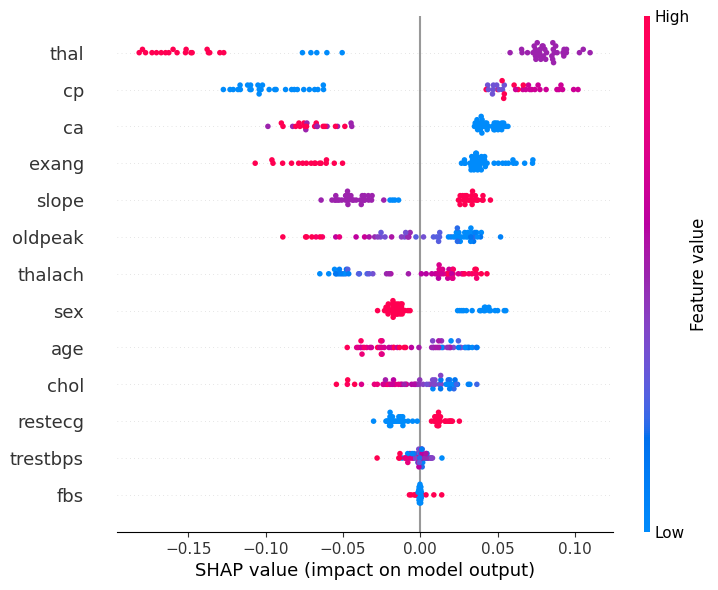

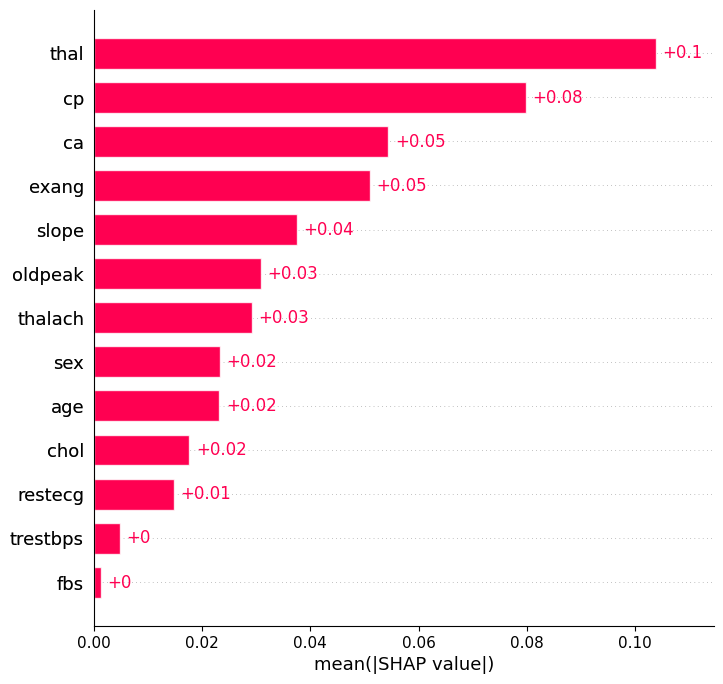

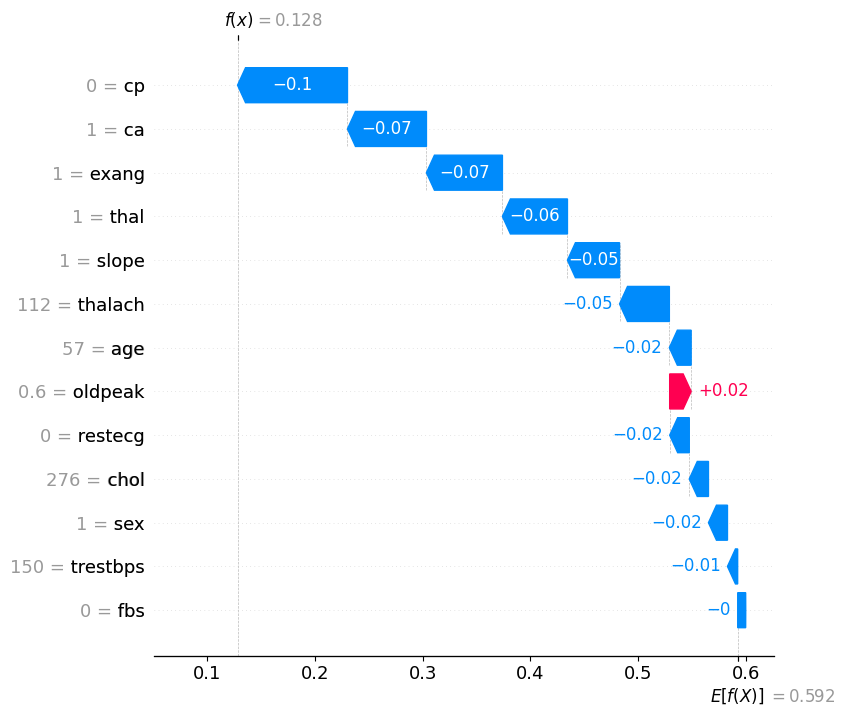

In [19]:
import shap
shap.initjs()

# Prediction function on raw data (positive class)
f = lambda X: rf_balanced.predict_proba(pd.DataFrame(X, columns=X_train.columns))[:, 1]

# Background sample for approximation (for speed: 100 samples is enough)
background = X_train.sample(n=min(100, len(X_train)), random_state=42)

# Simple Explainer (automatically selects KernelExplainer)
explainer = shap.Explainer(f, background)

# Compute SHAP values on the test set (you can pass a subset for speed)
shap_values = explainer(X_test)

# Plots
shap.plots.beeswarm(shap_values, max_display=15)       # Beeswarm plot (distribution of SHAP values)
shap.plots.bar(shap_values, max_display=15)            # Bar plot (mean absolute importance)
shap.plots.waterfall(shap_values[0], max_display=15)   # Waterfall plot for a single instance


**XGBoost — Hyperparameter Tuning and Balanced Selection**

Balanced XGBoost selection:
  params: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__scale_pos_weight': np.float64(0.8333333333333334), 'classifier__subsample': 0.8}
  CV AUC: 0.891  |  gap(train−cv): 0.088

Test metrics @0.5: AUC=0.904, F1=0.841, P=0.806, R=0.879
Confusion matrix:
 [[21  7]
 [ 4 29]]


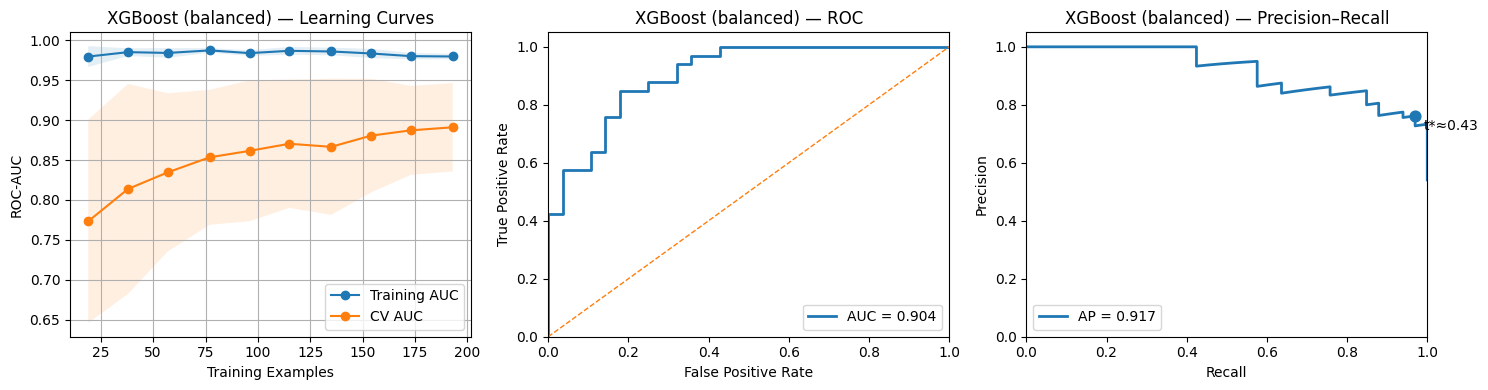


Metrics on TEST @ t* (F1-optimal)
AUC=0.904  AP=0.917  F1=0.853  P=0.762  R=0.970
Confusion matrix @ t*:
 [[18 10]
 [ 1 32]]


In [20]:
# ---- XGBoost Pipeline
pipe_xgb = Pipeline([
    ("prep", preprocess),
    ("classifier", XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42
    ))
])

# ---- Parameter grid
param_grid_xgb = {
    "classifier__n_estimators": [100, 200, 400],
    "classifier__max_depth": [3, 5, 7],
    "classifier__learning_rate": [0.01, 0.1, 0.2],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0],
    "classifier__scale_pos_weight": [1, (y_train.value_counts()[0] / y_train.value_counts()[1])]
}

# ---- Grid search with train/CV score storage
gs_xgb_raw = GridSearchCV(
    pipe_xgb,
    param_grid_xgb,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    refit=False,
    return_train_score=True
)
gs_xgb_raw.fit(X_train, y_train)

# ---- DataFrame of results
cvres_xgb = pd.DataFrame(gs_xgb_raw.cv_results_)
cvres_xgb["gap"] = cvres_xgb["mean_train_score"] - cvres_xgb["mean_test_score"]

# Balanced model selection
GAP_MAX = 0.05
subset_xgb = cvres_xgb[cvres_xgb["gap"] <= GAP_MAX]

if len(subset_xgb) > 0:
    best_row_xgb = subset_xgb.sort_values("mean_test_score", ascending=False).iloc[0]
else:
    alpha = 0.5
    cvres_xgb["objective"] = cvres_xgb["mean_test_score"] - alpha * cvres_xgb["gap"]
    best_row_xgb = cvres_xgb.sort_values("objective", ascending=False).iloc[0]

best_params_xgb = best_row_xgb["params"]
best_test_auc_xgb = best_row_xgb["mean_test_score"]
best_gap_xgb = best_row_xgb["gap"]

print("Balanced XGBoost selection:")
print("  params:", best_params_xgb)
print(f"  CV AUC: {best_test_auc_xgb:.3f}  |  gap(train−cv): {best_gap_xgb:.3f}")

# ---- Final model
xgb_balanced = pipe_xgb.set_params(**best_params_xgb)
xgb_balanced.fit(X_train, y_train)

# ---- Evaluation @ 0.5 threshold
y_proba_xgb = xgb_balanced.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_proba_xgb >= 0.5).astype(int)
print("\nTest metrics @0.5:",
      f"AUC={roc_auc_score(y_test, y_proba_xgb):.3f},",
      f"F1={f1_score(y_test, y_pred_xgb):.3f},",
      f"P={precision_score(y_test, y_pred_xgb):.3f},",
      f"R={recall_score(y_test, y_pred_xgb):.3f}")
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_xgb))

# ---- Learning curve
train_sizes_xgb, train_scores_xgb, val_scores_xgb = learning_curve(
    xgb_balanced, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv, scoring="roc_auc", n_jobs=-1
)
train_mean_xgb, train_std_xgb = train_scores_xgb.mean(axis=1), train_scores_xgb.std(axis=1)
val_mean_xgb, val_std_xgb = val_scores_xgb.mean(axis=1), val_scores_xgb.std(axis=1)

# ---- ROC / PR curves
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

prec_xgb, rec_xgb, pr_thr_xgb = precision_recall_curve(y_test, y_proba_xgb)
ap_xgb = average_precision_score(y_test, y_proba_xgb)

# Optimal F1 threshold
f1_curve_xgb = 2 * (prec_xgb[:-1] * rec_xgb[:-1]) / (prec_xgb[:-1] + rec_xgb[:-1] + 1e-12)
opt_idx_xgb = int(np.argmax(f1_curve_xgb))
t_star_xgb = pr_thr_xgb[opt_idx_xgb]
r_star_xgb, p_star_xgb = rec_xgb[opt_idx_xgb], prec_xgb[opt_idx_xgb]

# ---- Plot three charts
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (1) Learning curve
ax = axes[0]
ax.plot(train_sizes_xgb, train_mean_xgb, marker='o', label='Training AUC')
ax.fill_between(train_sizes_xgb, train_mean_xgb-train_std_xgb, train_mean_xgb+train_std_xgb, alpha=0.12)
ax.plot(train_sizes_xgb, val_mean_xgb, marker='o', label='CV AUC')
ax.fill_between(train_sizes_xgb, val_mean_xgb-val_std_xgb, val_mean_xgb+val_std_xgb, alpha=0.12)
ax.set_xlabel('Training Examples'); ax.set_ylabel('ROC-AUC')
ax.set_title('XGBoost (balanced) — Learning Curves')
ax.legend(loc='lower right'); ax.grid(True)

# (2) ROC curve
ax = axes[1]
ax.plot(fpr_xgb, tpr_xgb, lw=2, label=f'AUC = {roc_auc_xgb:.3f}')
ax.plot([0,1],[0,1], lw=1, linestyle='--')
ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('XGBoost (balanced) — ROC'); ax.legend(loc='lower right')

# (3) Precision–Recall curve
ax = axes[2]
ax.plot(rec_xgb, prec_xgb, lw=2, label=f'AP = {ap_xgb:.3f}')
ax.scatter(r_star_xgb, p_star_xgb, s=60)
ax.annotate(f"t*≈{t_star_xgb:.2f}", (r_star_xgb, p_star_xgb),
            textcoords="offset points", xytext=(6, -10))
ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('XGBoost (balanced) — Precision–Recall'); ax.legend(loc='lower left')

plt.tight_layout()
plt.show()

# ---- Metrics @ t*
y_pred_star_xgb = (y_proba_xgb >= t_star_xgb).astype(int)
print("\nMetrics on TEST @ t* (F1-optimal)")
print(f"AUC={roc_auc_xgb:.3f}  AP={ap_xgb:.3f}  "
      f"F1={f1_score(y_test, y_pred_star_xgb):.3f}  "
      f"P={precision_score(y_test, y_pred_star_xgb):.3f}  "
      f"R={recall_score(y_test, y_pred_star_xgb):.3f}")
print("Confusion matrix @ t*:\n", confusion_matrix(y_test, y_pred_star_xgb))


**SHAP for XGBoost**

PermutationExplainer explainer: 62it [00:19,  1.56it/s]


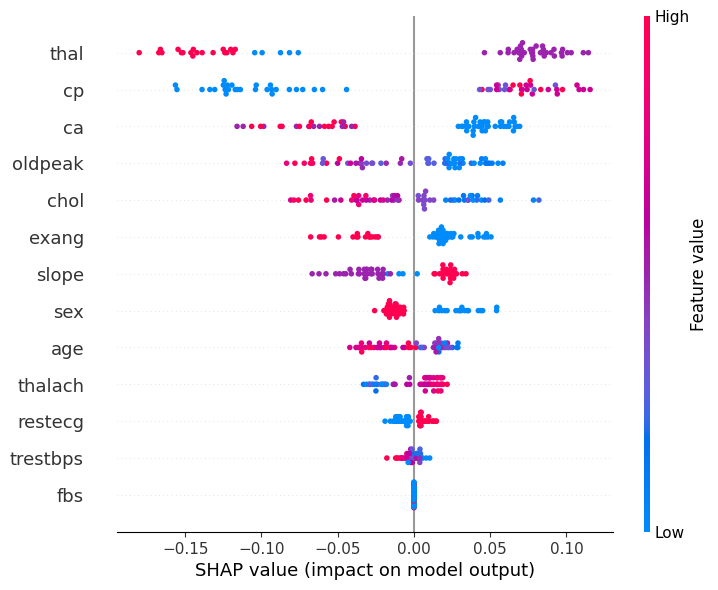

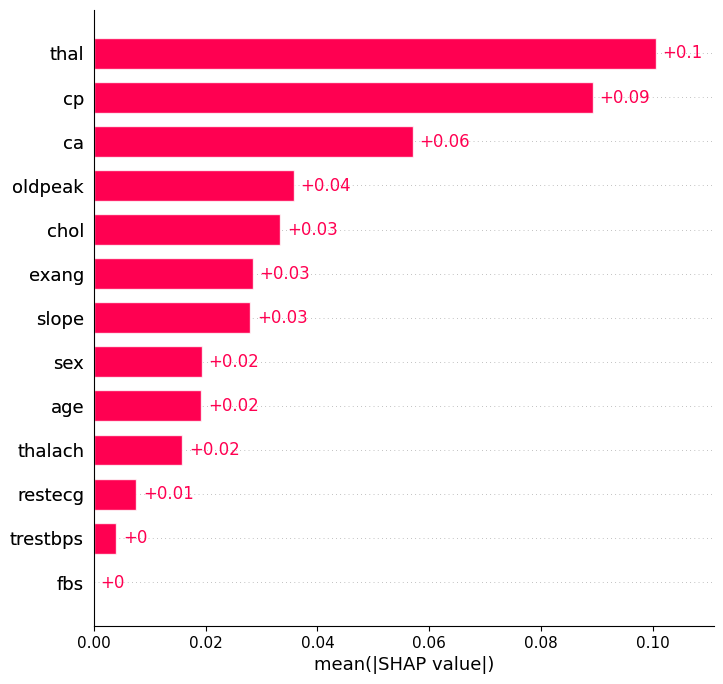

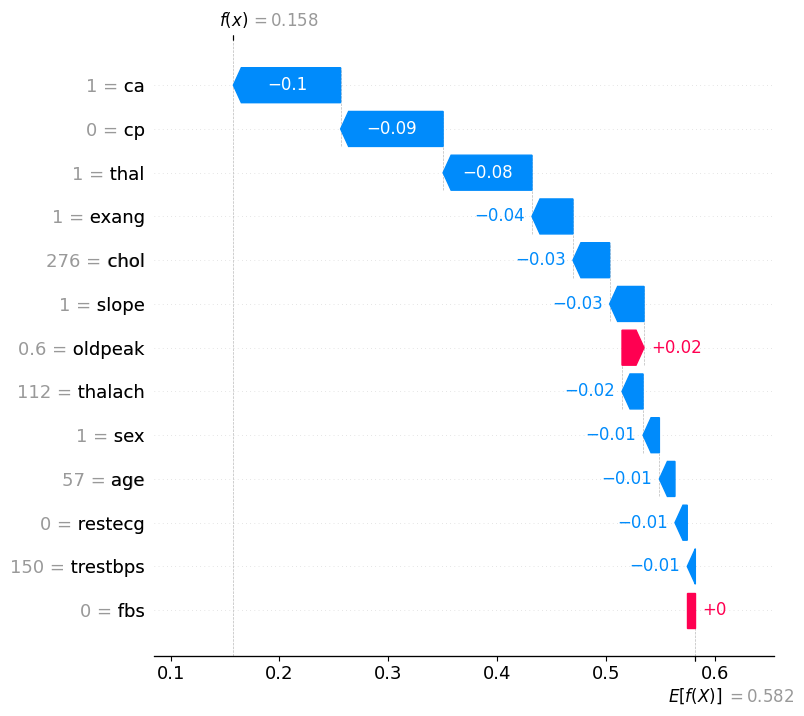

In [21]:
import shap

# If running in a notebook:
shap.initjs()

# --- Prediction function on raw X (positive class) ---
# Since the model is inside a Pipeline, we can simply pass the raw DataFrame with the same columns.
f = lambda X: xgb_balanced.predict_proba(pd.DataFrame(X, columns=X_train.columns))[:, 1]

# --- Background data for approximation (for speed: 100 samples is enough) ---
background = X_train.sample(n=min(100, len(X_train)), random_state=42)

# --- Simple Explainer (automatically chooses KernelExplainer) ---
explainer = shap.Explainer(f, background)

# --- Compute SHAP values for the test set (you can pass a smaller sample instead of the full test set) ---
shap_values = explainer(X_test)

# --- Common plots ---
# 1) Beeswarm plot (feature importance dispersion)
shap.plots.beeswarm(shap_values, max_display=15)

# 2) Bar plot (mean absolute SHAP values)
shap.plots.bar(shap_values, max_display=15)

# 3) Waterfall plot for a single instance (e.g., the first sample)
shap.plots.waterfall(shap_values[0], max_display=15)
